**Import Libraries**

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


**Load Dataset**

In [2]:
df = pd.read_excel("Laptop_price dataset.xlsx")

# 🔥 REMOVE unwanted column
df = df.drop(columns=["Column1"], errors="ignore")

df.head()


,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


**Separate Features and Target**

In [3]:
# Features
X = df[[
    "Brand",
    "Processor_Speed",
    "RAM_Size",
    "Storage_Capacity",
    "Screen_Size",
    "Weight"
]]

y = df["Price"]

# Encode categorical feature
le = LabelEncoder()
X["Brand"] = le.fit_transform(X["Brand"])

# Scale features
x_scaler = MinMaxScaler()
X_scaled = x_scaler.fit_transform(X)

# ---- TARGET NORMALIZATION (IMPORTANT) ----
y_scaler = MinMaxScaler()
y = y_scaler.fit_transform(df[["Price"]]).ravel()


**Train–Test Split (70–30)**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

X_train.shape, X_test.shape


((700, 6), (300, 6))

**MODEL TRAINING**

In [5]:
# Multiple Linear Regression (MLR)
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)


In [6]:
# Artificial Neural Network (ANN)
ann = MLPRegressor(
    hidden_layer_sizes=(50, 50),
    solver='adam',
    max_iter=1000,
    random_state=42
)

ann.fit(X_train, y_train)
y_pred_ann = ann.predict(X_test)


In [7]:
#Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [8]:
# Support Vector Regressor (SVR)
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)


In [9]:
# Convert normalized values back to original price
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

y_pred_mlr_actual = y_scaler.inverse_transform(y_pred_mlr.reshape(-1, 1)).ravel()
y_pred_ann_actual = y_scaler.inverse_transform(y_pred_ann.reshape(-1, 1)).ravel()
y_pred_rf_actual  = y_scaler.inverse_transform(y_pred_rf.reshape(-1, 1)).ravel()
y_pred_svr_actual = y_scaler.inverse_transform(y_pred_svr.reshape(-1, 1)).ravel()


**EVALUATION**

In [10]:
def mape_safe(y_true, y_pred, eps=1e-8):
    y_true = np.where(y_true == 0, eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [11]:
#For RMSE, MAE, R²
def evaluate_scaled(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


In [12]:
# For MAPE
def evaluate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [13]:
# RESULTS TABLE
results = pd.DataFrame({
    "Model": ["MLR", "ANN", "Random Forest", "SVR"],

    "RMSE": [
        evaluate_scaled(y_test, y_pred_mlr)[0],
        evaluate_scaled(y_test, y_pred_ann)[0],
        evaluate_scaled(y_test, y_pred_rf)[0],
        evaluate_scaled(y_test, y_pred_svr)[0]
    ],

    "MAE": [
        evaluate_scaled(y_test, y_pred_mlr)[1],
        evaluate_scaled(y_test, y_pred_ann)[1],
        evaluate_scaled(y_test, y_pred_rf)[1],
        evaluate_scaled(y_test, y_pred_svr)[1]
    ],

    "MAPE (%)": [
        evaluate_mape(y_test_actual, y_pred_mlr_actual),
        evaluate_mape(y_test_actual, y_pred_ann_actual),
        evaluate_mape(y_test_actual, y_pred_rf_actual),
        evaluate_mape(y_test_actual, y_pred_svr_actual)
    ],

    "R2 Score": [
        evaluate_scaled(y_test, y_pred_mlr)[2],
        evaluate_scaled(y_test, y_pred_ann)[2],
        evaluate_scaled(y_test, y_pred_rf)[2],
        evaluate_scaled(y_test, y_pred_svr)[2]
    ]
})

results


,Model,RMSE,MAE,MAPE (%),R2 Score
0,MLR,0.007644,0.006118,0.977307,0.999589
1,ANN,0.024401,0.019030,3.119091,0.995813
2,Random Forest,0.008615,0.006909,1.112921,0.999478
3,SVR,0.056938,0.044999,7.713014,0.977201


In [14]:
# ROUND VALUES
results_display = results.copy()

results_display["RMSE"] = results_display["RMSE"].round(2)
results_display["MAE"] = results_display["MAE"].round(2)
results_display["MAPE (%)"] = results_display["MAPE (%)"].round(2)
results_display["R2 Score"] = results_display["R2 Score"].round(2)

results_display


,Model,RMSE,MAE,MAPE (%),R2 Score
0,MLR,0.01,0.01,0.98,1.00
1,ANN,0.02,0.02,3.12,1.00
2,Random Forest,0.01,0.01,1.11,1.00
3,SVR,0.06,0.04,7.71,0.98


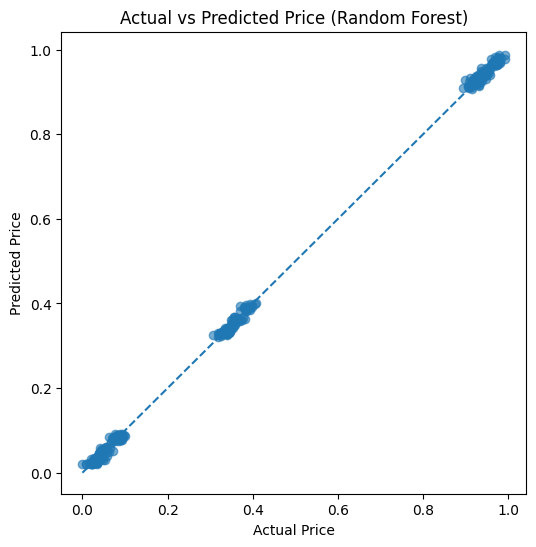

In [15]:
# Actual vs Predicted (Random Forest)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Random Forest)")
plt.show()

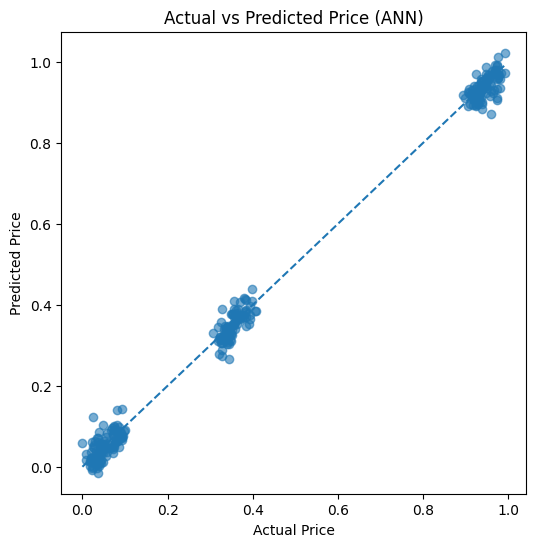

In [16]:
# Actual vs Predicted (ANN)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ann, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (ANN)")
plt.show()

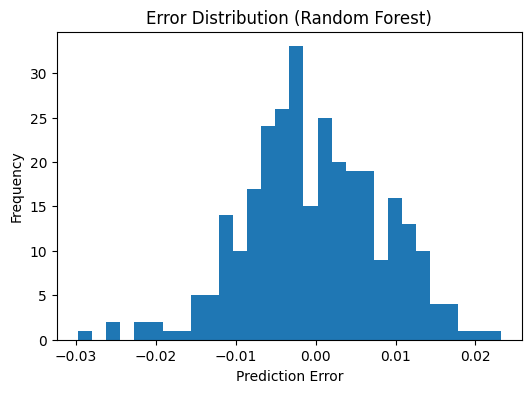

In [17]:
# Error Distribution (Random Forest)
errors_rf = y_test - y_pred_rf

plt.figure(figsize=(6,4))
plt.hist(errors_rf, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Random Forest)")
plt.show()


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_scaled(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


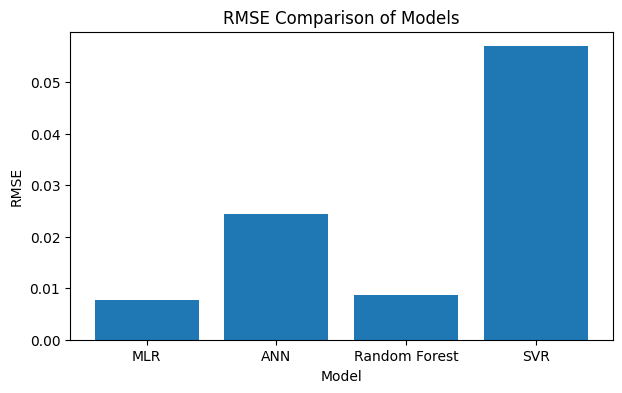

In [19]:
# Model Comparison (RMSE)
models = ["MLR", "ANN", "Random Forest", "SVR"]
rmse_values = [
    evaluate_scaled(y_test, y_pred_mlr)[0],
    evaluate_scaled(y_test, y_pred_ann)[0],
    evaluate_scaled(y_test, y_pred_rf)[0],
    evaluate_scaled(y_test, y_pred_svr)[0]
]

plt.figure(figsize=(7,4))
plt.bar(models, rmse_values)
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Models")
plt.show()